<h1 style="text-align:center;">IMMREP23 TCRs specific to B0801_RAKFKQLL</h1>

In [21]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from Bio.PDB import MMCIFParser, PDBIO, PDBParser, Superimposer, Model, Structure
from Bio.PDB.SASA import ShrakeRupley
from Bio.SeqUtils import seq1
from scipy.spatial import cKDTree

from collections import defaultdict
from scipy.stats import spearmanr

from sklearn.metrics import roc_curve, roc_auc_score

# Prepare AF3 input

In [18]:
df = pd.read_csv('/Users/roessner/Documents/PostDoc/Data/TCR_data/EpitopeSpecific/PublicDatabases/full_dataset_TCR-epitope_clean_study.csv')
df = df[(df['study'] == 'IMMREP23') & (df['model'] == 'B0801_RAKFKQLL')]

df = df[['TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'cdr3_TRA', 'cdr3_TRB']]
df = df.dropna()

tcr_ids = np.array([f'tcr_{i+1:04d}' for i in range(len(df))])
df.insert(0, 'id', tcr_ids)
df['peptide'] = 'RAKFKQLL'
df['species'] = 'HomoSapiens'
df['MHC'] = 'HLA_B0801'

df.to_csv('B0801_RAKFKQLL_IMMREP23.csv', index=False)

In [19]:
# curate negatives
topdir = '/Users/roessner/Documents/PostDoc/Data/TCR_data/Repertoires/'
df = pd.read_parquet(f"{topdir}/df_sel_studies_ireceptor_pairs_allele_and_NO_allele_merged.parquet")

n_total = len(pd.read_csv('B0801_RAKFKQLL_IMMREP23.csv'))
studies = df['study_id'].unique()
n_per_study = max(1, n_total // len(studies))

samples = []

for study in studies:
    study_df = df[df['study_id'] == study]
    
    subjects = study_df['subject_id'].unique()
    n_per_subject = max(1, n_per_study // len(subjects))
    
    sampled_study = (
        study_df.groupby('subject_id', group_keys=False)
                .apply(lambda x: x.sample(min(len(x), n_per_subject), random_state=42))
    )
    
    samples.append(sampled_study)

sampled = pd.concat(samples)
sampled = sampled.sample(min(len(sampled), 1000), random_state=42)[['TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'cdr3_TRA', 'cdr3_TRB']]
sampled.insert(0, 'id', [f'tcr_{i:04d}' for i in range(1, len(sampled) + 1)])
sampled['peptide'] = 'RAKFKQLL'
sampled['MHC'] = 'HLA_B0801'
sampled['species'] = 'HomoSapiens'
sampled.to_csv('B0801_RAKFKQLL_neg_repertoire.csv', index=False)

/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_21192/2740863582.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), n_per_subject), random_state=42))
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_21192/2740863582.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), n_per_subject), random_state=42))
/var/fol

# AUROC

/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_21192/4155318307.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{batch}/{batch}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_21192/4155318307.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{batch}/{batch}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]


98
62


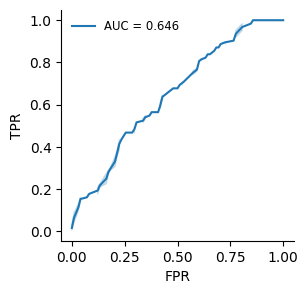

In [24]:
batches = {'negative' : 'B0801_RAKFKQLL_neg_repertoire', 'positive' : 'B0801_RAKFKQLL_IMMREP23'}

for name, batch in batches.items():
    df = pd.read_csv(f'{batch}/{batch}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
    print(len(df))
    if name == 'positive':
        scores_pos = df["AF3_iptm_pair_mean"].values
    else:
        scores_neg = df["AF3_iptm_pair_mean"].values

# create labels
y_true = np.concatenate([
    np.ones(len(scores_pos)),      # positives = 1
    np.zeros(len(scores_neg))      # negatives = 0
])

# combine scores
y_scores = np.concatenate([scores_pos, scores_neg])

# compute ROC
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
auc = roc_auc_score(y_true, y_scores)

fig, ax = plt.subplots(1,1,figsize=(3,3))
sns.lineplot(x=fpr, y=tpr, label=f"AUC = {auc:.3f}", ax=ax)

ax.legend(frameon=False, fontsize='small')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
sns.despine()